# データサイエンス特論 第7回 事前課題
青山学院大学大学院 理工学研究科 理工学専攻 知能情報コース 修士1年 35626302 森下剛

#### 事前課題1

In [49]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import t

In [50]:
def t_plot_fill_rejection(mu, sigma, df, xrange, p):
    start = mu - xrange * sigma
    end = mu + xrange * sigma

    X = np.arange(start, end, 0.01)
    Y = t.pdf(X, df=df, loc=mu, scale=sigma)

    fig, ax = plt.subplots()
    ax.plot(X, Y, color='blue')

    alpha = 1 - p
    x_upper = t.ppf(1 - alpha / 2, df=df, loc=mu, scale=sigma)

    X_upper = np.arange(x_upper, end, 0.001)
    ax.fill_between(X_upper, t.pdf(X_upper, df=df, loc=mu, scale=sigma), color='red', alpha=0.5)

    ax.set_xlabel('X')
    ax.set_ylabel('Probability density')
    ax.set_title(f'rejection region')
    plt.show()

In [51]:
n = 10
r = 0.23

t_0 = (np.abs(r) * np.sqrt(n - 2)) / np.sqrt(1 - r * r)
df = n - 2
alpha = 0.025

t_lower = t.ppf(alpha / 2, df=df)
t_upper = t.ppf(1 - alpha / 2, df=df)

print(f't_0 = {t_0}')
print(f'下側0.5%点 = {t_lower}, 上側0.5%点 = {t_upper}')

t_0 = 0.6684592097730407
下側0.5%点 = -2.751523596063053, 上側0.5%点 = 2.7515235960630537


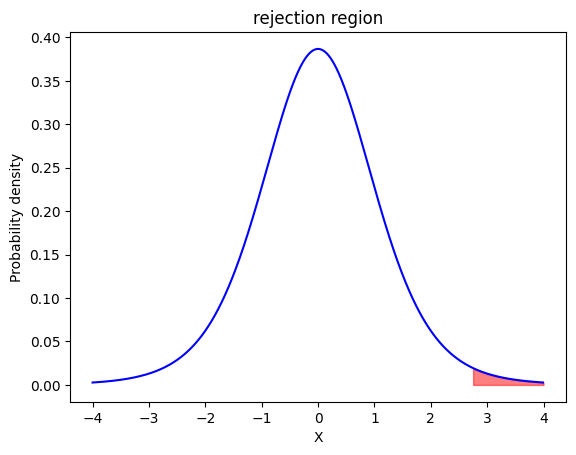

In [52]:
t_plot_fill_rejection(mu=0, sigma=1, df=df, xrange=4, p=1 - alpha)

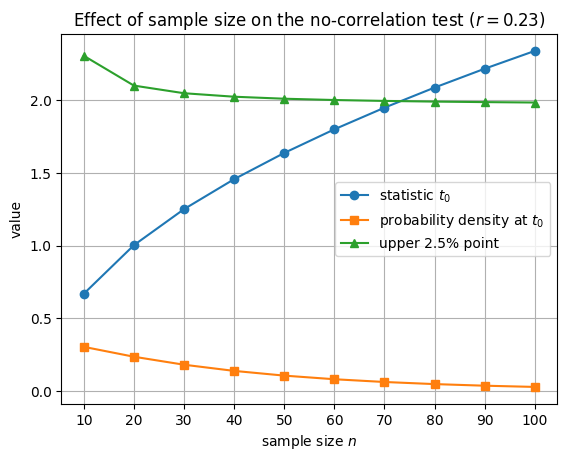

In [53]:
r = 0.23
alpha = 0.025
sample_sizes = np.arange(10, 101, 10)

t_0_list = []
density_list = []
upper_list = []

for n in sample_sizes:
    df = n - 2
    t_0 = (np.abs(r) * np.sqrt(n - 2)) / np.sqrt(1 - r ** 2)
    density = t.pdf(t_0, df=df)
    upper = t.ppf(1 - alpha, df=df)

    t_0_list.append(t_0)
    density_list.append(density)
    upper_list.append(upper)

fig, ax = plt.subplots()
ax.plot(sample_sizes, t_0_list, marker='o', label='statistic $t_0$')
ax.plot(sample_sizes, density_list, marker='s', label='probability density at $t_0$')
ax.plot(sample_sizes, upper_list, marker='^', label='upper 2.5% point')

ax.set_xlabel('sample size $n$')
ax.set_ylabel('value')
ax.set_title('Effect of sample size on the no-correlation test ($r = 0.23$)')
ax.set_xticks(sample_sizes)
ax.legend()
ax.grid(True)
plt.show()

標本数を増やす統計量t_0値が2.5%点に近くなり、標本数70を超えたあたりで棄却域に入る。p値はt_0の変化にともなって単調減少し、分布の中央から裾の方に移動することを意味する。
標本数を増やすと棄却域に入るので真値としては「2変量間に相関がない」という帰無仮説は棄却できる。